In [3]:
import pandas as pd
import numpy as np

# Configuración de aleatoriedad para reproducibilidad
np.random.seed(42)
n_rows = 1000

# 1. Variables Demográficas
edad = np.random.randint(1, 85, n_rows)
sexo = np.random.choice(['M', 'F'], n_rows, p=[0.7, 0.3]) # Más común en hombres por labores agrícolas
etnia = np.random.choice(['Indigena', 'Afro', 'Otros'], n_rows, p=[0.1, 0.15, 0.75])
regimen_salud = np.random.choice(['Subsidiado', 'Contributivo', 'No Asegurado'], n_rows, p=[0.6, 0.3, 0.1])

# 2. Variables Geográficas y de Contexto
departamento = np.random.choice(['Antioquia', 'Casanare', 'Chocó', 'Meta', 'Amazonas'], n_rows)
area_ocurrencia = np.random.choice(['Rural Disperso', 'Centro Poblado', 'Cabecera Municipal'], n_rows, p=[0.6, 0.2, 0.2])
actividad_momento = np.random.choice(['Agricultura', 'Tránsito por trocha', 'Recreación', 'Doméstico'], n_rows, p=[0.6, 0.2, 0.1, 0.1])

# 3. Variables del Evento Ofídico
# Géneros comunes en Colombia: Bothrops (Talla X), Crotalus (Cascabel), Micrurus (Coral), Lachesis (Verrugosa)
genero_serpiente = np.random.choice(['Bothrops', 'Crotalus', 'Micrurus', 'Lachesis', 'Desconocido'], n_rows, p=[0.7, 0.1, 0.05, 0.05, 0.1])
localizacion_mordedura = np.random.choice(['Miembros Inferiores', 'Miembros Superiores', 'Tronco/Cabeza'], n_rows, p=[0.8, 0.15, 0.05])

# 4. Variables de Oportunidad y Clínica
tiempo_atencion_horas = np.random.gamma(shape=2, scale=3, size=n_rows) # Distribución sesgada a la derecha
uso_medicina_tradicional = np.random.choice([1, 0], n_rows, p=[0.3, 0.7]) # (Rezo, emplastos, etc.)
presencia_edema = np.random.choice([1, 0], n_rows, p=[0.8, 0.2])
presencia_sangrado = np.random.choice([1, 0], n_rows, p=[0.4, 0.6])
flictenas = np.random.choice([1, 0], n_rows, p=[0.2, 0.8]) # (ampollas) - corrected variable name
uso_suero_antiofidico_prehospitalario = np.random.choice([1, 0], n_rows, p=[0.1, 0.9])

# --- Generación de la Variable Objetivo (Hospitalización) ---
# Creamos un score de riesgo para que los datos no sean puramente aleatorios
logit = (
    0.5 * (tiempo_atencion_horas > 6) +
    0.8 * (area_ocurrencia == 'Rural Disperso') +
    1.2 * (genero_serpiente == 'Crotalus') +
    1.5 * (genero_serpiente == 'Lachesis') +
    0.7 * (presencia_sangrado) +
    0.5 * (uso_medicina_tradicional) -
    1.0 # Intercepto base
)
prob = 1 / (1 + np.exp(-logit))
hospitalizacion = np.where(prob > np.random.rand(n_rows), 1, 0)

# Crear DataFrame
df_ofidico = pd.DataFrame({
    'edad': edad,
    'sexo': sexo,
    'etnia': etnia,
    'regimen_salud': regimen_salud,
    'departamento': departamento,
    'area_ocurrencia': area_ocurrencia,
    'actividad': actividad_momento,
    'genero_serpiente': genero_serpiente,
    'localizacion_mordedura': localizacion_mordedura,
    'tiempo_atencion_h': tiempo_atencion_horas.round(1),
    'medicina_tradicional': uso_medicina_tradicional,
    'edema': presencia_edema,
    'sangrado': presencia_sangrado,
    'flictenas': flictenas,
    'suero_previo': uso_suero_antiofidico_prehospitalario,
    'hospitalizacion': hospitalizacion
})

df_ofidico.head()
# df_ofidico.to_csv('datos_ofidico_colombia.csv', index=False)

,edad,sexo,etnia,regimen_salud,departamento,area_ocurrencia,actividad,genero_serpiente,localizacion_mordedura,tiempo_atencion_h,medicina_tradicional,edema,sangrado,flictenas,suero_previo,hospitalizacion
0,52,M,Otros,No Asegurado,Chocó,Rural Disperso,Agricultura,Crotalus,Miembros Inferiores,8.1,0,1,1,0,0,1
1,15,F,Otros,Subsidiado,Amazonas,Rural Disperso,Tránsito por trocha,Bothrops,Miembros Superiores,7.8,0,1,0,0,0,1
2,72,F,Otros,Subsidiado,Amazonas,Cabecera Municipal,Doméstico,Bothrops,Miembros Inferiores,6.9,0,1,1,0,0,1
3,61,M,Otros,Contributivo,Casanare,Rural Disperso,Agricultura,Bothrops,Miembros Inferiores,2.8,0,1,0,0,0,0
4,21,M,Afro,Subsidiado,Amazonas,Centro Poblado,Agricultura,Bothrops,Miembros Superiores,4.3,0,1,0,0,0,0


## Análisis Exploratorio de Datos (EDA)

Esta sección se dedicará a comprender la estructura de los datos, identificar patrones, detectar anomalías y preparar los datos para futuros análisis o modelado. Incluirá un vistazo general a la información del DataFrame, estadísticas descriptivas y la verificación de valores faltantes.

### 1. Vista General de los Datos

Primero, obtendremos una visión general de la información del DataFrame, incluyendo tipos de datos, número de entradas no nulas y el uso de memoria. Luego, mostraremos las estadísticas descriptivas de las columnas numéricas y el tamaño del DataFrame.

In [4]:
print('Información del DataFrame:')
df_ofidico.info()

print('\nEstadísticas descriptivas de las variables numéricas:')
display(df_ofidico.describe())

print(f'Dimensiones del DataFrame: {df_ofidico.shape[0]} filas, {df_ofidico.shape[1]} columnas')

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    1000 non-null   int64  
 1   sexo                    1000 non-null   object 
 2   etnia                   1000 non-null   object 
 3   regimen_salud           1000 non-null   object 
 4   departamento            1000 non-null   object 
 5   area_ocurrencia         1000 non-null   object 
 6   actividad               1000 non-null   object 
 7   genero_serpiente        1000 non-null   object 
 8   localizacion_mordedura  1000 non-null   object 
 9   tiempo_atencion_h       1000 non-null   float64
 10  medicina_tradicional    1000 non-null   int64  
 11  edema                   1000 non-null   int64  
 12  sangrado                1000 non-null   int64  
 13  flictenas               1000 non-null   int64  
 14  suero_previo  

,edad,tiempo_atencion_h,medicina_tradicional,edema,sangrado,flictenas,suero_previo,hospitalizacion
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.485000,6.013000,0.297000,0.806000,0.411000,0.197000,0.088000,0.580000
std,23.923296,4.173122,0.457165,0.395627,0.492261,0.397931,0.283437,0.493805
min,1.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,2.875000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,5.150000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,61.000000,8.225000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,84.000000,30.600000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Dimensiones del DataFrame: 1000 filas, 16 columnas


### 2. Verificación de Valores Faltantes

Es crucial identificar cualquier valor faltante en el dataset, ya que pueden afectar la calidad del análisis y el rendimiento de los modelos.

In [5]:
print('Valores faltantes por columna:')
display(df_ofidico.isnull().sum().to_frame(name='Valores Faltantes'))

print(f'Total de valores faltantes en el DataFrame: {df_ofidico.isnull().sum().sum()}')

Valores faltantes por columna:


,Valores Faltantes
edad,0
sexo,0
etnia,0
regimen_salud,0
departamento,0
area_ocurrencia,0
actividad,0
genero_serpiente,0
localizacion_mordedura,0
tiempo_atencion_h,0


Total de valores faltantes en el DataFrame: 0


### 3. Análisis de Variables Categóricas

Exploraremos la distribución de las variables categóricas para entender las proporciones de cada categoría y su relación con la variable objetivo `hospitalizacion`.

/tmp/ipykernel_1426/2022520792.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ofidico, x=col, palette='viridis')
/tmp/ipykernel_1426/2022520792.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ofidico, x=col, palette='viridis')
/tmp/ipykernel_1426/2022520792.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ofidico, x=col, palette='viridis')
/tmp/ipykernel_1426/2022520792.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

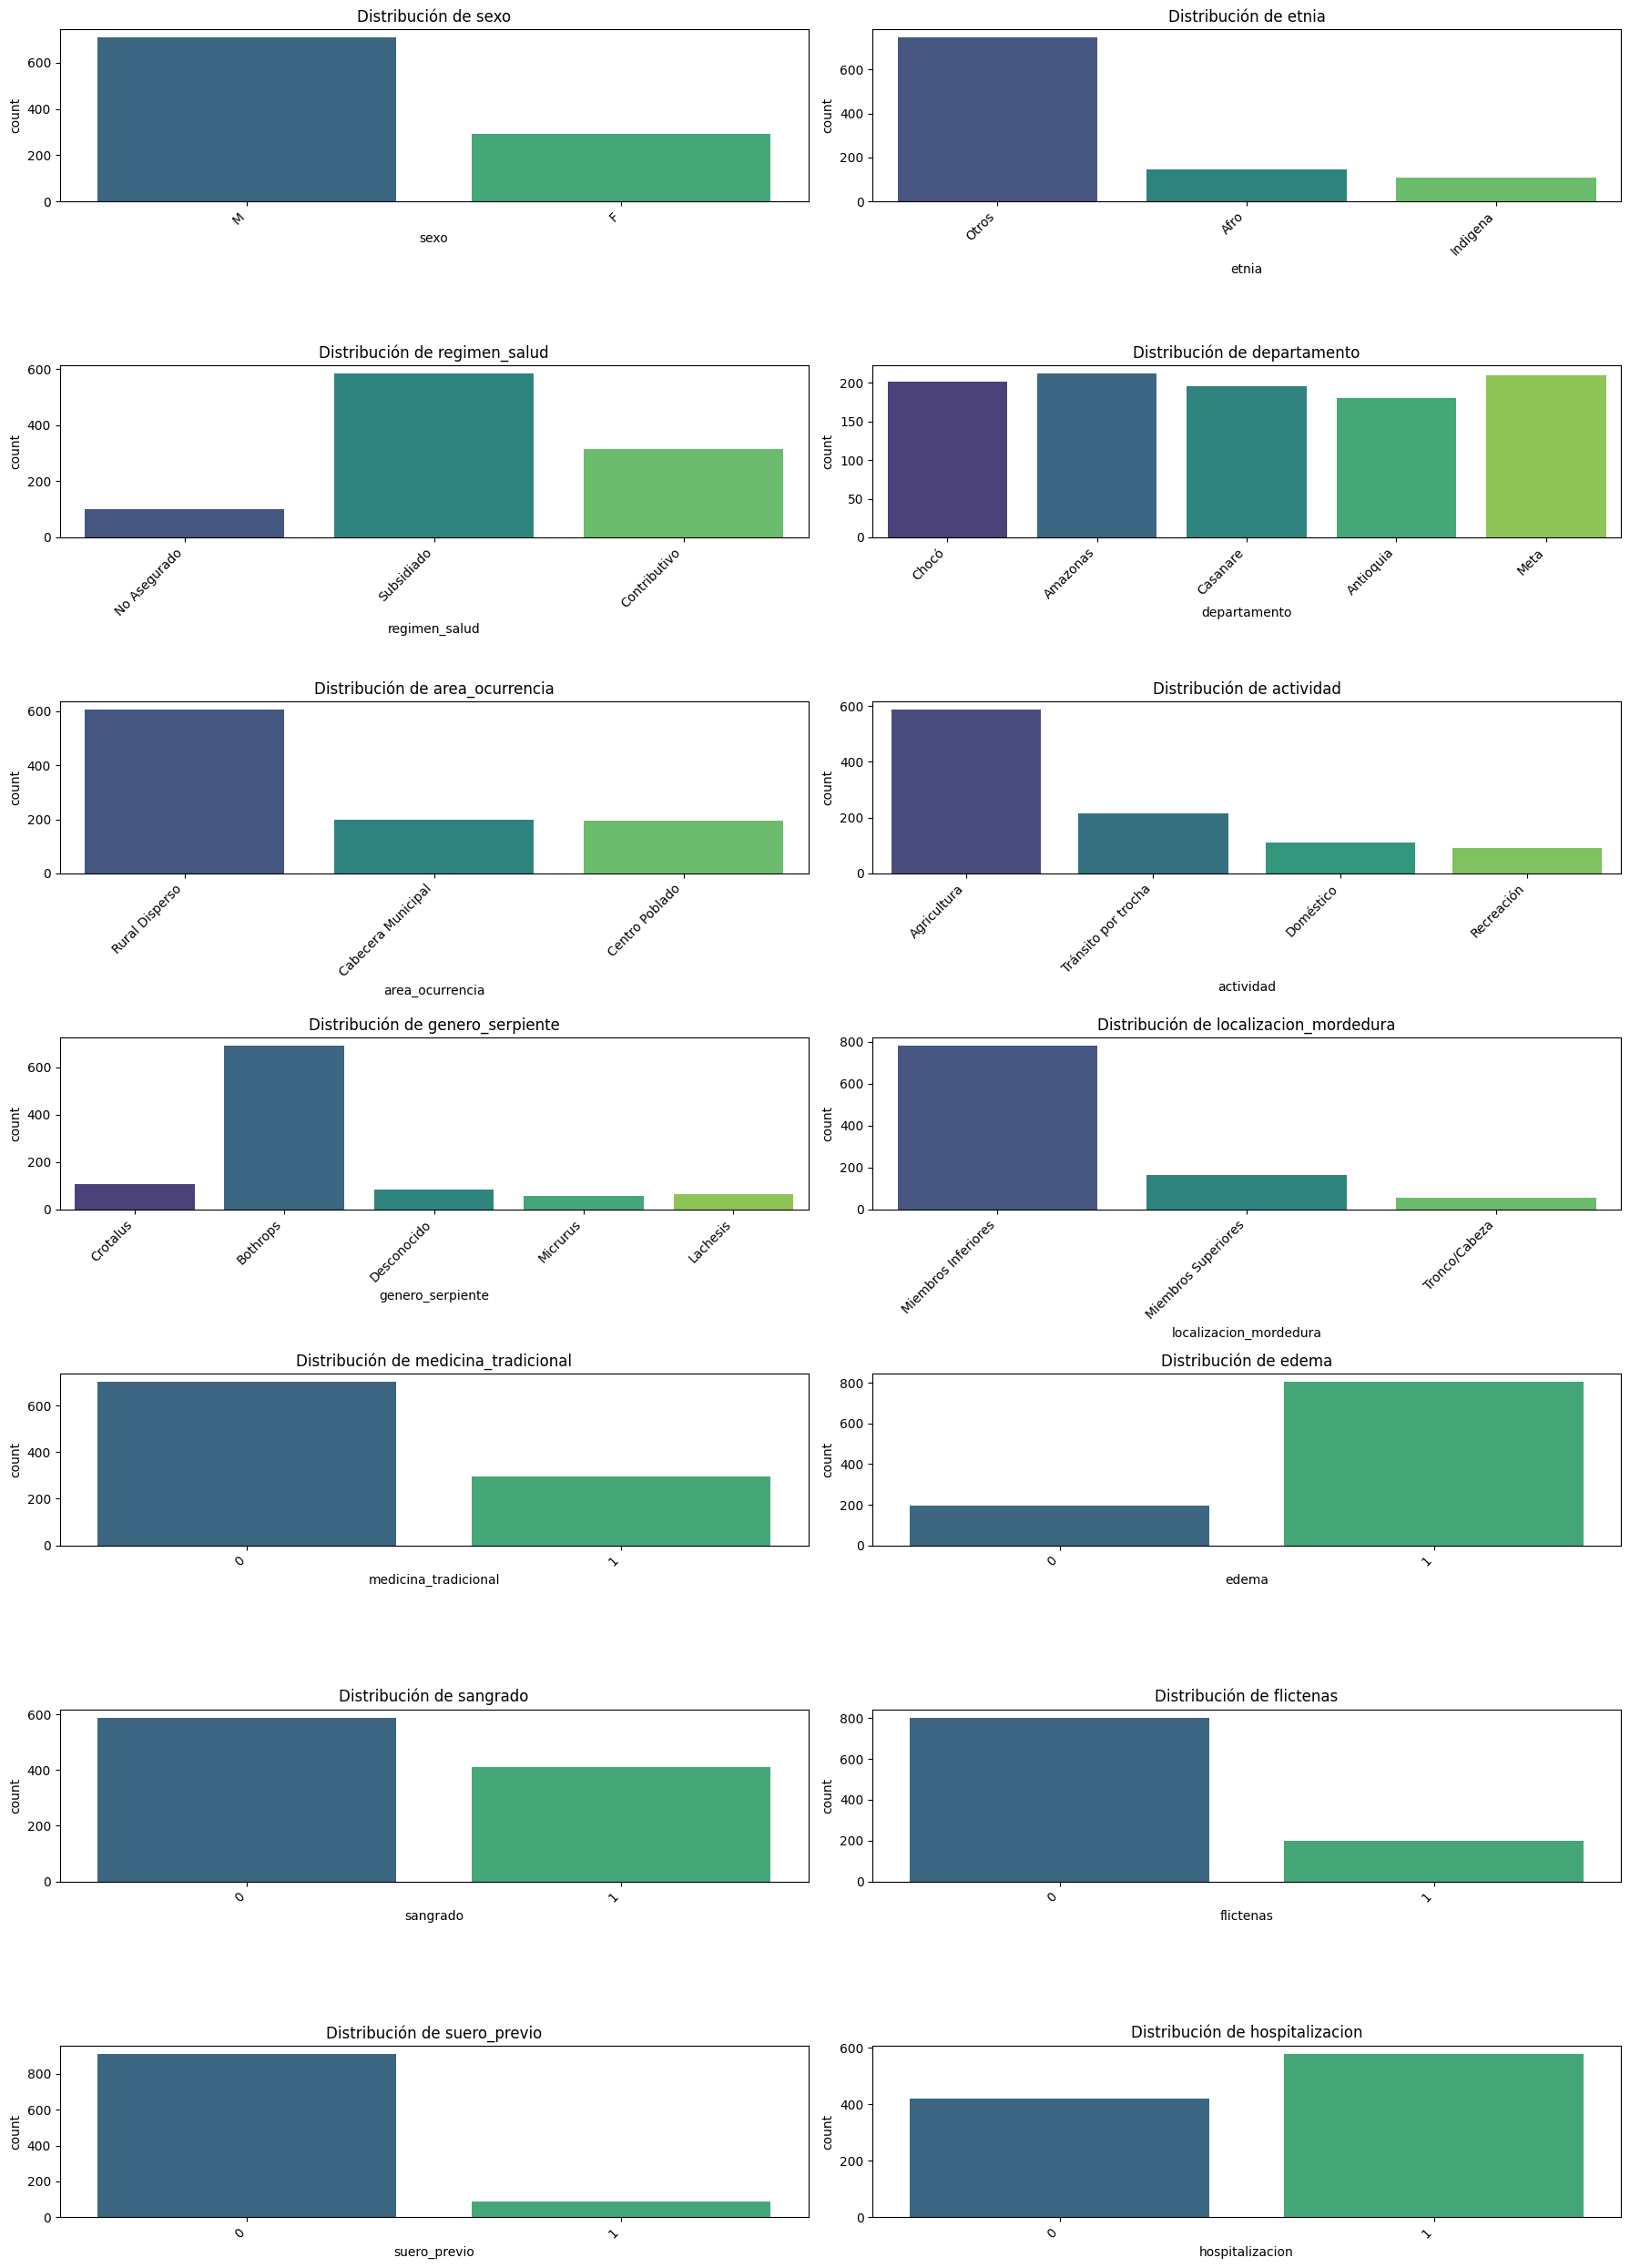

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'sexo', 'etnia', 'regimen_salud', 'departamento',
    'area_ocurrencia', 'actividad', 'genero_serpiente',
    'localizacion_mordedura', 'medicina_tradicional', 'edema',
    'sangrado', 'flictenas', 'suero_previo', 'hospitalizacion'
]

plt.figure(figsize=(18, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(7, 2, i + 1) # Ajustar el tamaño de la cuadrícula según el número de columnas
    sns.countplot(data=df_ofidico, x=col, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Análisis de la Relación entre Variables Categóricas y Hospitalización

Observaremos cómo cada variable categórica se relaciona con la probabilidad de `hospitalizacion`.

/tmp/ipykernel_1426/1197283056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ofidico, x=col, y='hospitalizacion', palette='muted')
/tmp/ipykernel_1426/1197283056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ofidico, x=col, y='hospitalizacion', palette='muted')
/tmp/ipykernel_1426/1197283056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ofidico, x=col, y='hospitalizacion', palette='muted')
/tmp/ipykernel_1426/1197283056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

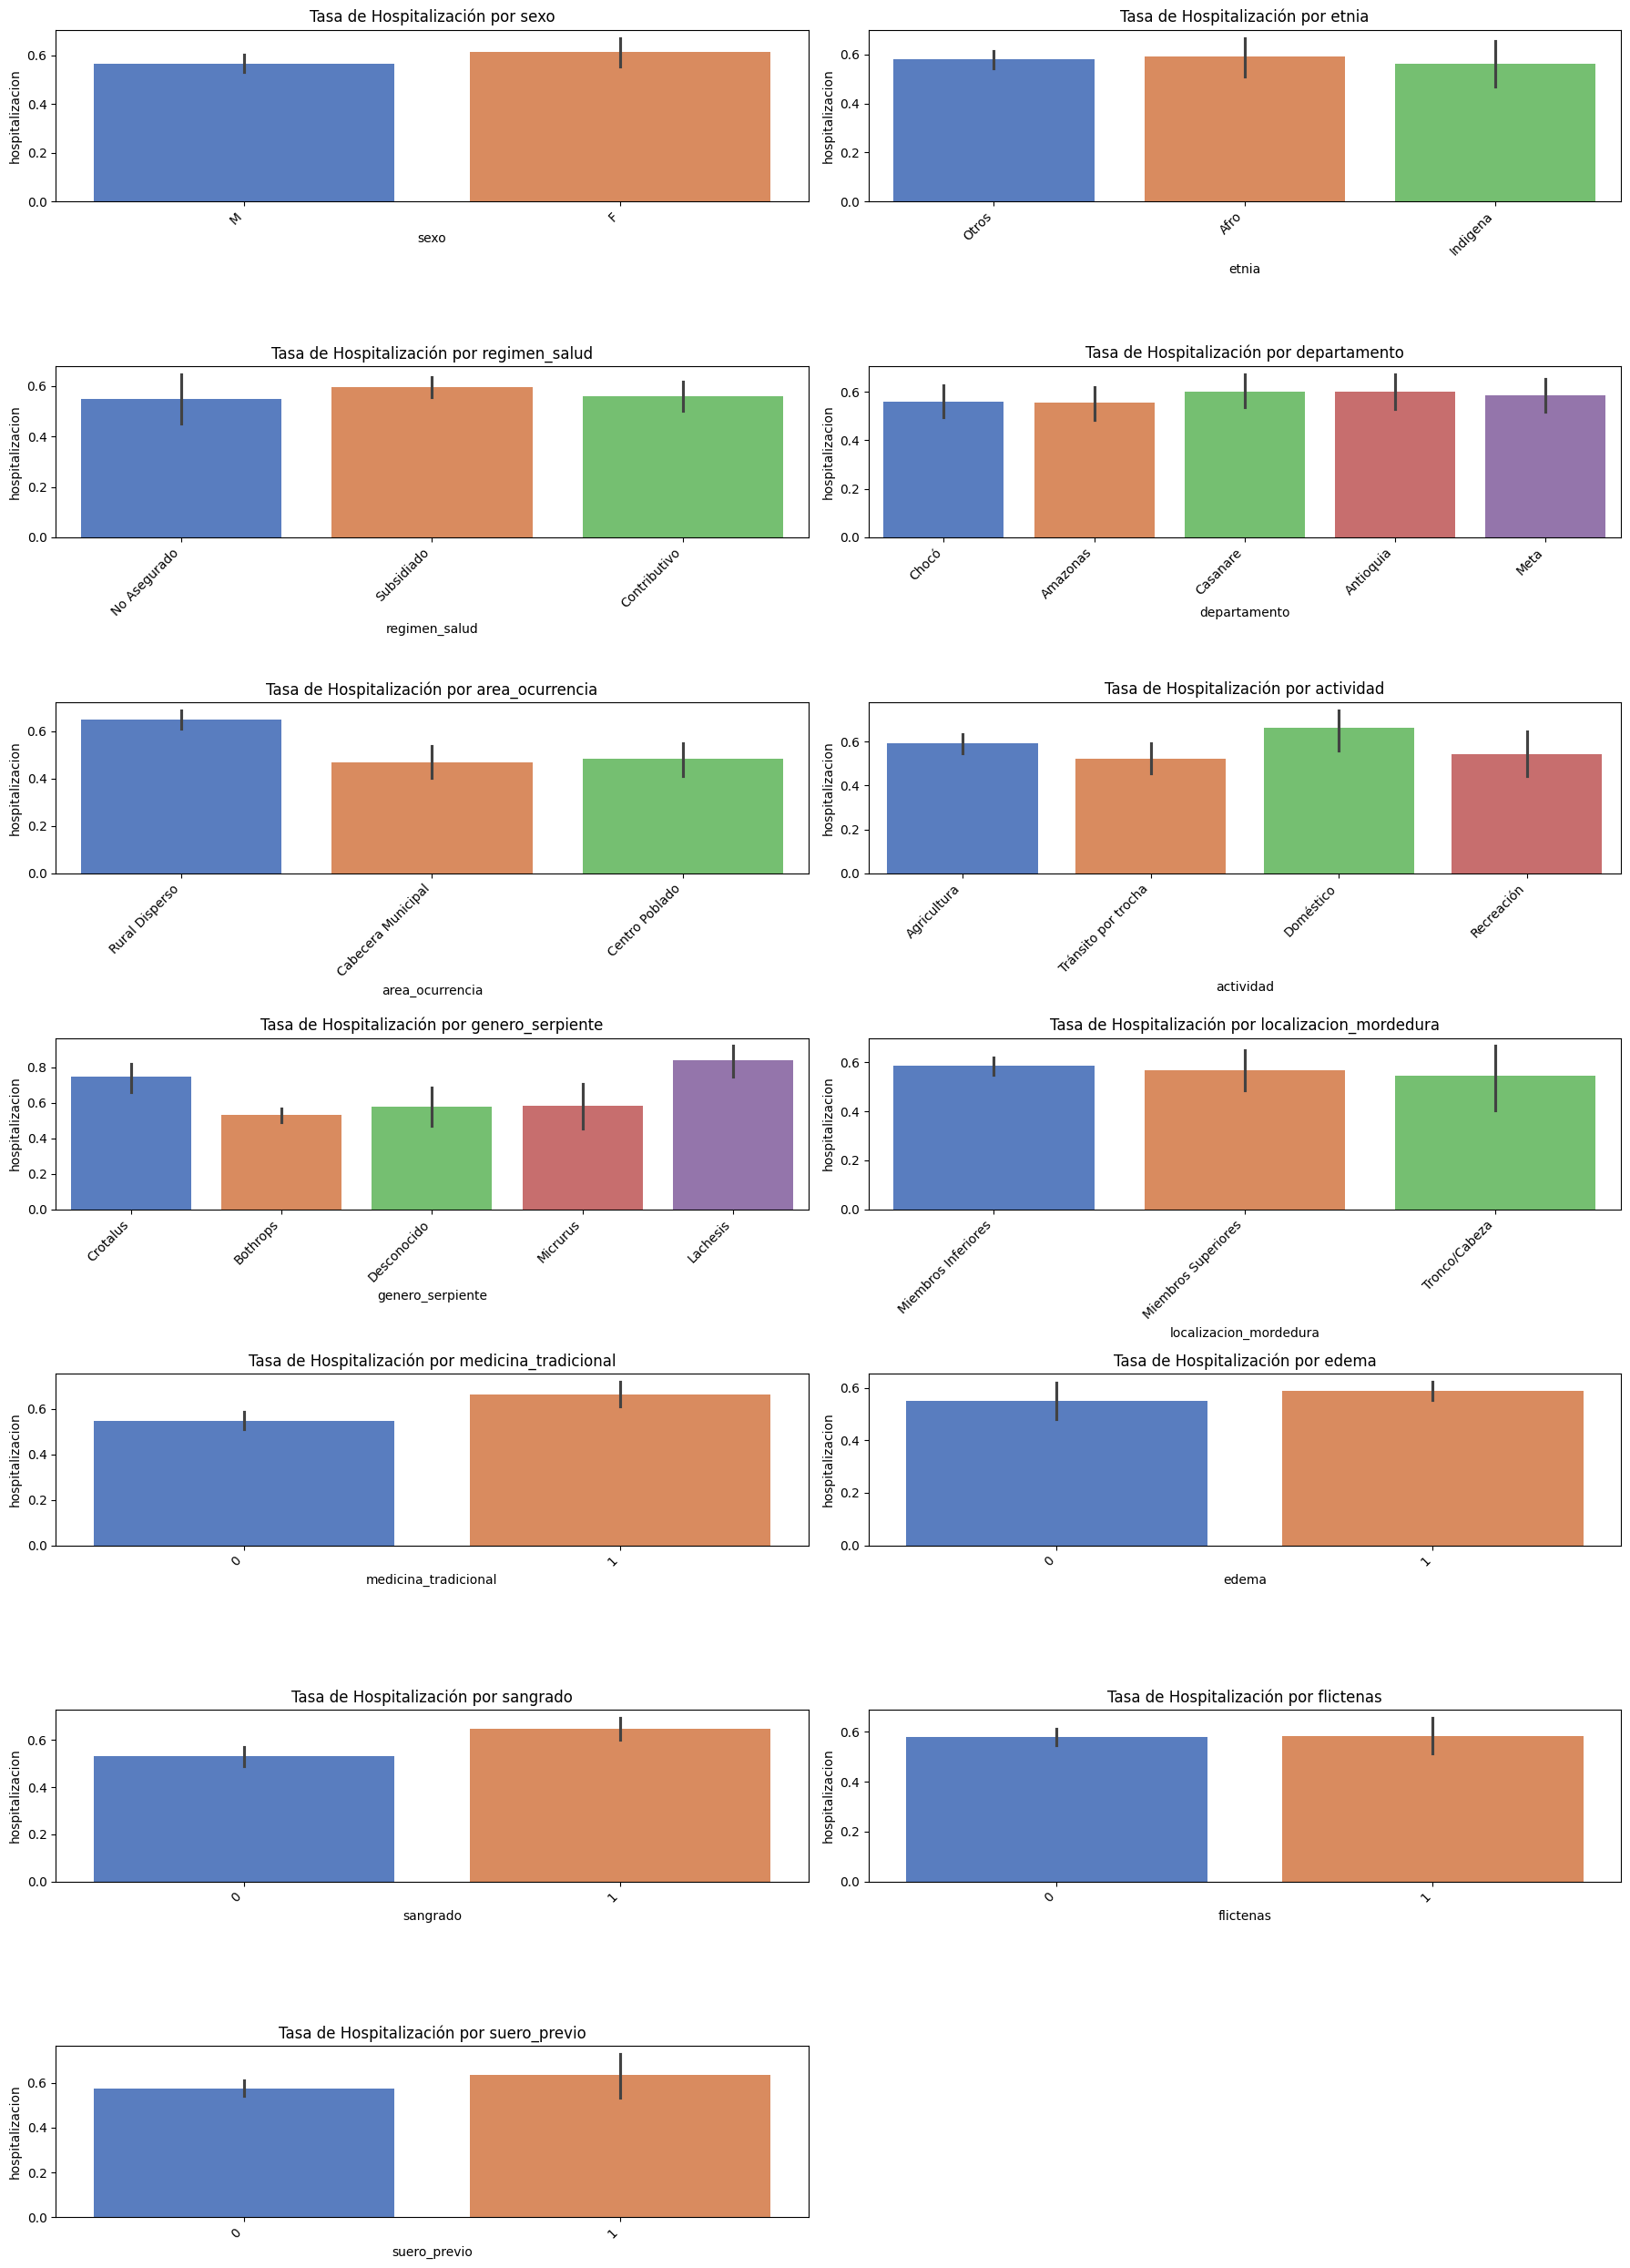

In [7]:
plt.figure(figsize=(18, 25))
for i, col in enumerate(categorical_cols[:-1]): # Excluir 'hospitalizacion' de la lista de columnas explicativas
    plt.subplot(7, 2, i + 1)
    sns.barplot(data=df_ofidico, x=col, y='hospitalizacion', palette='muted')
    plt.title(f'Tasa de Hospitalización por {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Análisis de Variables Numéricas

Visualizaremos la distribución de las variables numéricas (`edad`, `tiempo_atencion_h`) utilizando histogramas y gráficos de densidad (KDE).

/tmp/ipykernel_1426/3209651527.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_ofidico[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_1426/3209651527.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_ofidico[col], kde=True, bins=30, palette='viridis')


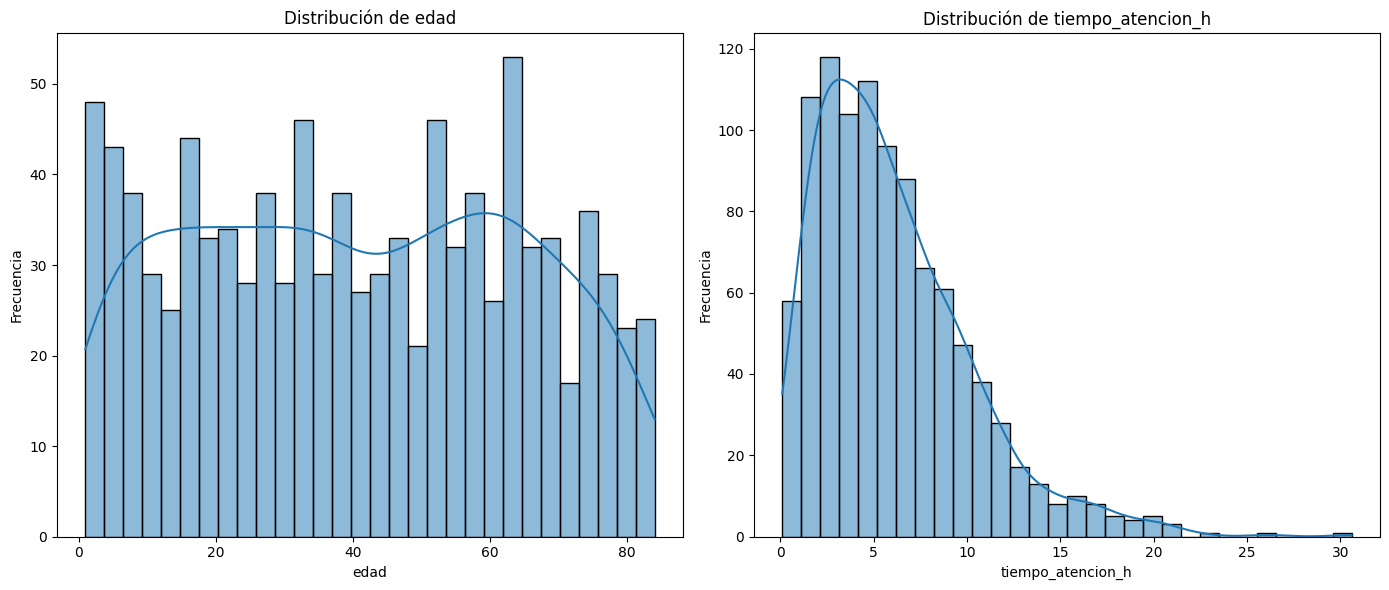

In [8]:
numerical_cols = ['edad', 'tiempo_atencion_h']

plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df_ofidico[col], kde=True, bins=30, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 6. Relación entre Variables Numéricas y Hospitalización

Analizaremos la relación entre `edad`, `tiempo_atencion_h` y la variable objetivo `hospitalizacion` usando boxplots.

/tmp/ipykernel_1426/1085943368.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ofidico, x='hospitalizacion', y=col, palette='pastel')
/tmp/ipykernel_1426/1085943368.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ofidico, x='hospitalizacion', y=col, palette='pastel')


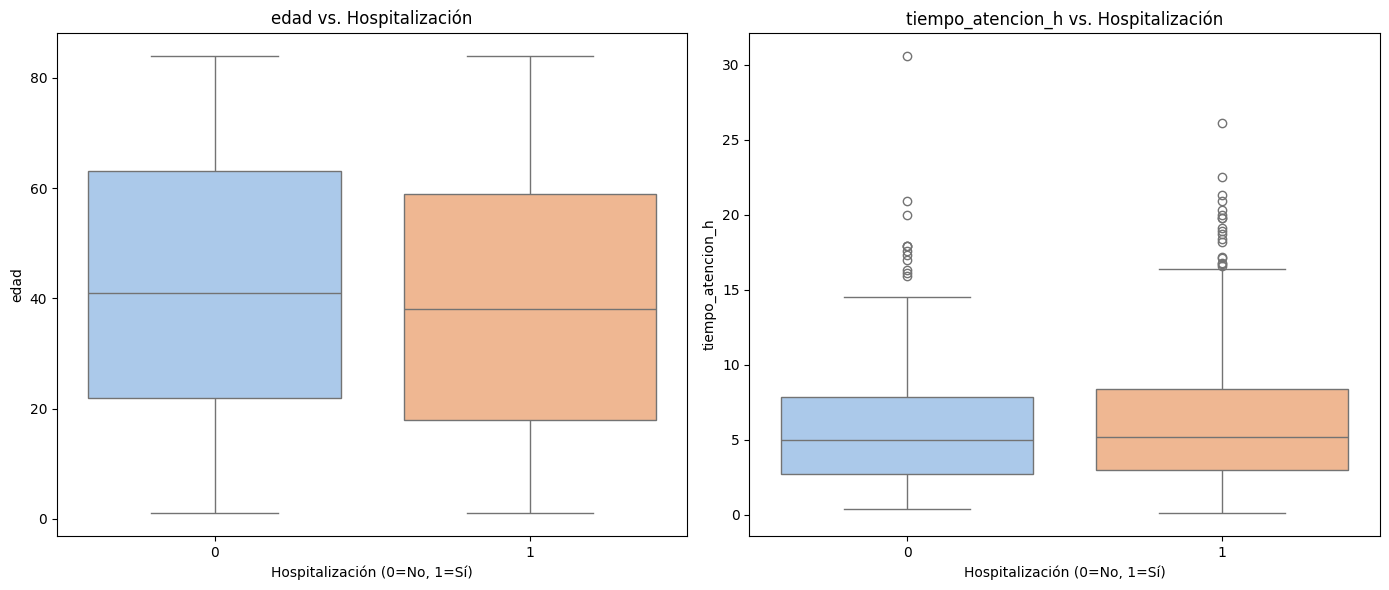

In [9]:
plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(data=df_ofidico, x='hospitalizacion', y=col, palette='pastel')
    plt.title(f'{col} vs. Hospitalización')
    plt.xlabel('Hospitalización (0=No, 1=Sí)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Ingeniería de Características

En esta sección, crearemos nuevas características a partir de las existentes o transformaremos las actuales para mejorar la capacidad predictiva del modelo. Esto puede incluir la agrupación de edades, la categorización del tiempo de atención o la codificación de variables categóricas.

### 1. Creación de Categorías de Edad

Crearemos una nueva característica `edad_categoria` para agrupar las edades en rangos significativos.

Distribución de la nueva característica edad_categoria:


,count
edad_categoria,
Adulto,500
Adulto Mayor,273
Niño,144
Adolescente,83


/tmp/ipykernel_1426/3646011064.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ofidico, x='edad_categoria', palette='viridis', order=labels)


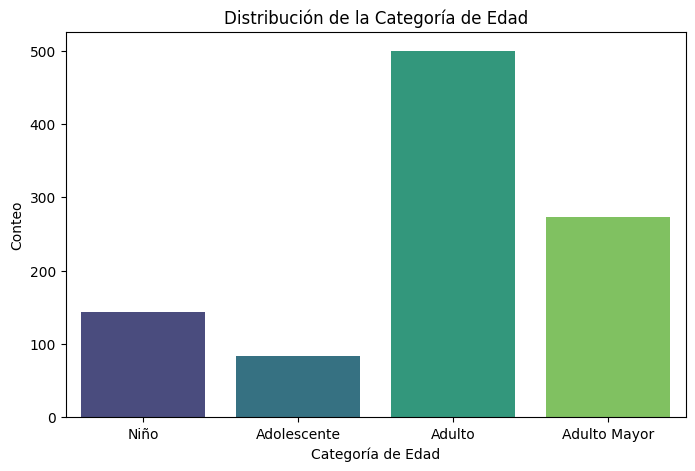

In [10]:
bins = [0, 12, 18, 60, 85]
labels = ['Niño', 'Adolescente', 'Adulto', 'Adulto Mayor']
df_ofidico['edad_categoria'] = pd.cut(df_ofidico['edad'], bins=bins, labels=labels, right=False)

print('Distribución de la nueva característica edad_categoria:')
display(df_ofidico['edad_categoria'].value_counts().to_frame())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_ofidico, x='edad_categoria', palette='viridis', order=labels)
plt.title('Distribución de la Categoría de Edad')
plt.xlabel('Categoría de Edad')
plt.ylabel('Conteo')
plt.show()

### 2. Creación de Categorías de Tiempo de Atención

Crearemos una nueva característica `tiempo_atencion_categoria` para agrupar el tiempo de atención en rangos que puedan indicar la urgencia o la demora.

Distribución de la nueva característica tiempo_atencion_categoria:


,count
tiempo_atencion_categoria,
Tardía (6-12h),334
Moderada (3-6h),321
Rápida (<3h),259
Muy Tardía (>12h),86


/tmp/ipykernel_1426/641646640.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ofidico, x='tiempo_atencion_categoria', palette='cividis', order=labels_tiempo)


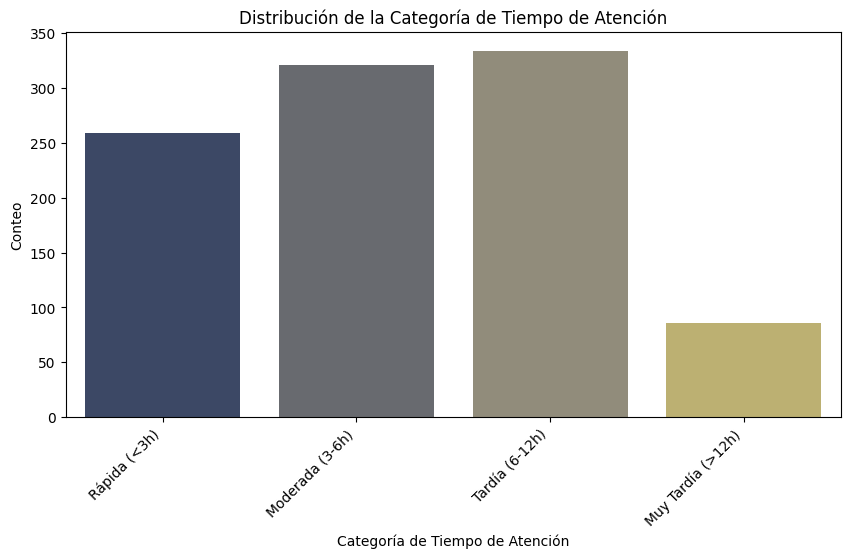

In [11]:
bins_tiempo = [0, 3, 6, 12, df_ofidico['tiempo_atencion_h'].max() + 1]
labels_tiempo = ['Rápida (<3h)', 'Moderada (3-6h)', 'Tardía (6-12h)', 'Muy Tardía (>12h)']
df_ofidico['tiempo_atencion_categoria'] = pd.cut(df_ofidico['tiempo_atencion_h'], bins=bins_tiempo, labels=labels_tiempo, right=False)

print('Distribución de la nueva característica tiempo_atencion_categoria:')
display(df_ofidico['tiempo_atencion_categoria'].value_counts().to_frame())

plt.figure(figsize=(10, 5))
sns.countplot(data=df_ofidico, x='tiempo_atencion_categoria', palette='cividis', order=labels_tiempo)
plt.title('Distribución de la Categoría de Tiempo de Atención')
plt.xlabel('Categoría de Tiempo de Atención')
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.show()

### 3. Codificación de Variables Categóricas (One-Hot Encoding)

Para preparar los datos para el modelado, codificaremos las variables categóricas utilizando One-Hot Encoding. Esto convierte las categorías en un formato binario que los algoritmos de aprendizaje automático pueden procesar.

In [12]:
df_encoded = pd.get_dummies(df_ofidico, columns=categorical_cols[:-1] + ['edad_categoria', 'tiempo_atencion_categoria'], drop_first=True)

print('Primeras 5 filas del DataFrame con variables codificadas:')
display(df_encoded.head())

print(f'Dimensiones del DataFrame codificado: {df_encoded.shape[0]} filas, {df_encoded.shape[1]} columnas')


Primeras 5 filas del DataFrame con variables codificadas:


,edad,tiempo_atencion_h,hospitalizacion,sexo_M,etnia_Indigena,etnia_Otros,regimen_salud_No Asegurado,regimen_salud_Subsidiado,departamento_Antioquia,departamento_Casanare,...,edema_1,sangrado_1,flictenas_1,suero_previo_1,edad_categoria_Adolescente,edad_categoria_Adulto,edad_categoria_Adulto Mayor,tiempo_atencion_categoria_Moderada (3-6h),tiempo_atencion_categoria_Tardía (6-12h),tiempo_atencion_categoria_Muy Tardía (>12h)
0,52,8.1,1,True,False,True,True,False,False,False,...,True,True,False,False,False,True,False,False,True,False
1,15,7.8,1,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,True,False
2,72,6.9,1,False,False,True,False,True,False,False,...,True,True,False,False,False,False,True,False,True,False
3,61,2.8,0,True,False,True,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
4,21,4.3,0,True,False,False,False,True,False,False,...,True,False,False,False,False,True,False,True,False,False


Dimensiones del DataFrame codificado: 1000 filas, 34 columnas


## Modelado y Evaluación

En esta sección, prepararemos los datos para el modelado, entrenaremos un modelo de clasificación para predecir la `hospitalizacion` y evaluaremos su rendimiento utilizando métricas clave.

### 1. Separación de Datos (Entrenamiento y Prueba)

Antes de entrenar cualquier modelo, es fundamental dividir el conjunto de datos en dos subconjuntos: uno para el entrenamiento (que el modelo 'aprenderá') y otro para la prueba (para evaluar el rendimiento del modelo en datos no vistos). Utilizaremos una proporción 80/20 para entrenamiento y prueba, respectivamente.

In [13]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = df_encoded.drop('hospitalizacion', axis=1)
y = df_encoded['hospitalizacion']

# Separar los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Dimensiones del conjunto de entrenamiento de características (X_train): {X_train.shape}')
print(f'Dimensiones del conjunto de prueba de características (X_test): {X_test.shape}')
print(f'Dimensiones del conjunto de entrenamiento de la variable objetivo (y_train): {y_train.shape}')
print(f'Dimensiones del conjunto de prueba de la variable objetivo (y_test): {y_test.shape}')

Dimensiones del conjunto de entrenamiento de características (X_train): (800, 33)
Dimensiones del conjunto de prueba de características (X_test): (200, 33)
Dimensiones del conjunto de entrenamiento de la variable objetivo (y_train): (800,)
Dimensiones del conjunto de prueba de la variable objetivo (y_test): (200,)


### 2. Entrenamiento del Modelo (Regresión Logística)

Para esta tarea de clasificación binaria (`hospitalizacion`), utilizaremos un modelo de Regresión Logística. Es un algoritmo simple pero efectivo, ideal como punto de partida.

In [14]:
from sklearn.linear_model import LogisticRegression

# Inicializar el modelo de Regresión Logística
# Se usa max_iter para asegurar la convergencia con los datos.
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print('¡Modelo de Regresión Logística entrenado exitosamente!')

¡Modelo de Regresión Logística entrenado exitosamente!


### 3. Predicciones del Modelo

Una vez que el modelo está entrenado, lo usaremos para hacer predicciones sobre el conjunto de prueba, datos que el modelo no ha visto antes.

In [15]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Predicciones realizadas en el conjunto de prueba.')

Predicciones realizadas en el conjunto de prueba.


### 4. Evaluación del Modelo

Ahora evaluaremos el rendimiento de nuestro modelo utilizando una variedad de métricas de clasificación, incluyendo la matriz de confusión y la curva ROC.

Accuracy: 0.6350
Precision: 0.6617
Recall: 0.7586
F1-Score: 0.7068
ROC AUC Score: 0.6645


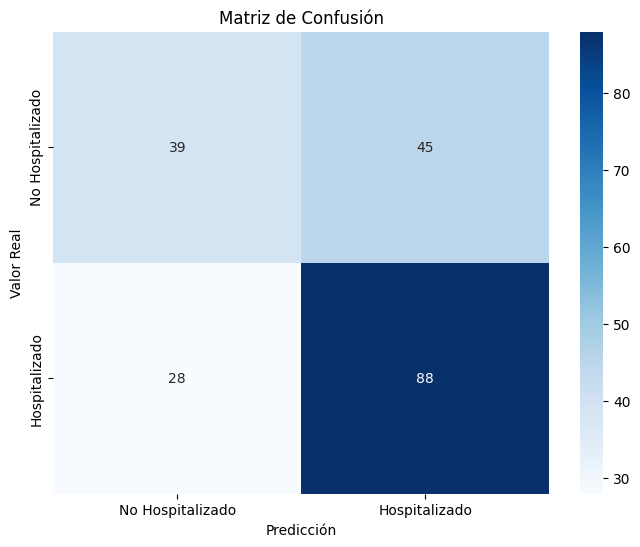

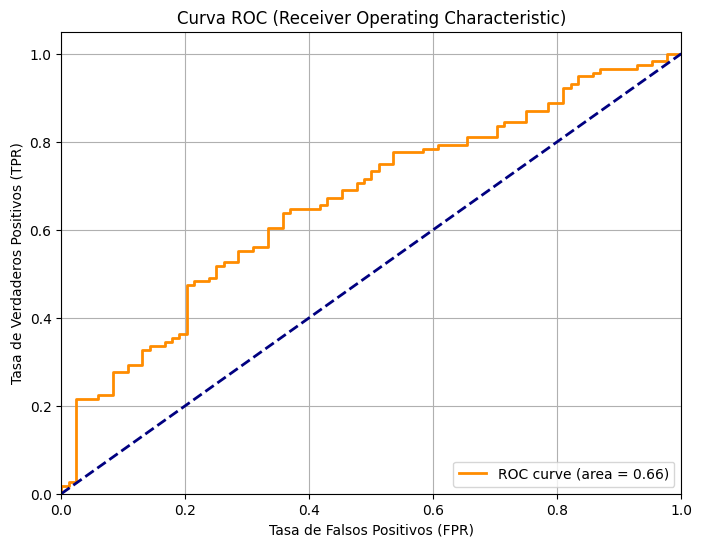

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular y mostrar métricas de clasificación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC AUC Score: {roc_auc:.4f}')

# Mostrar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Hospitalizado', 'Hospitalizado'],
            yticklabels=['No Hospitalizado', 'Hospitalizado'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Mostrar la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 5. Análisis de Importancia de Características del Modelo de Regresión Logística

Vamos a extraer los coeficientes de nuestro modelo de Regresión Logística. En este tipo de modelos, la magnitud de los coeficientes (en valor absoluto) puede interpretarse como la importancia de una característica para la predicción de la variable objetivo. Los coeficientes positivos indican una relación directa con la probabilidad de hospitalización, y los negativos, una relación inversa.

Top 10 características más importantes según la Regresión Logística:


,Feature,Coefficient,Abs_Coefficient
18,genero_serpiente_Lachesis,1.216001,1.216001
16,genero_serpiente_Crotalus,0.950522,0.950522
12,area_ocurrencia_Rural Disperso,0.709416,0.709416
22,medicina_tradicional_1,0.508105,0.508105
24,sangrado_1,0.500964,0.500964
15,actividad_Tránsito por trocha,-0.349092,0.349092
32,tiempo_atencion_categoria_Muy Tardía (>12h),0.296408,0.296408
14,actividad_Recreación,-0.272917,0.272917
7,departamento_Antioquia,0.239204,0.239204
17,genero_serpiente_Desconocido,0.228396,0.228396


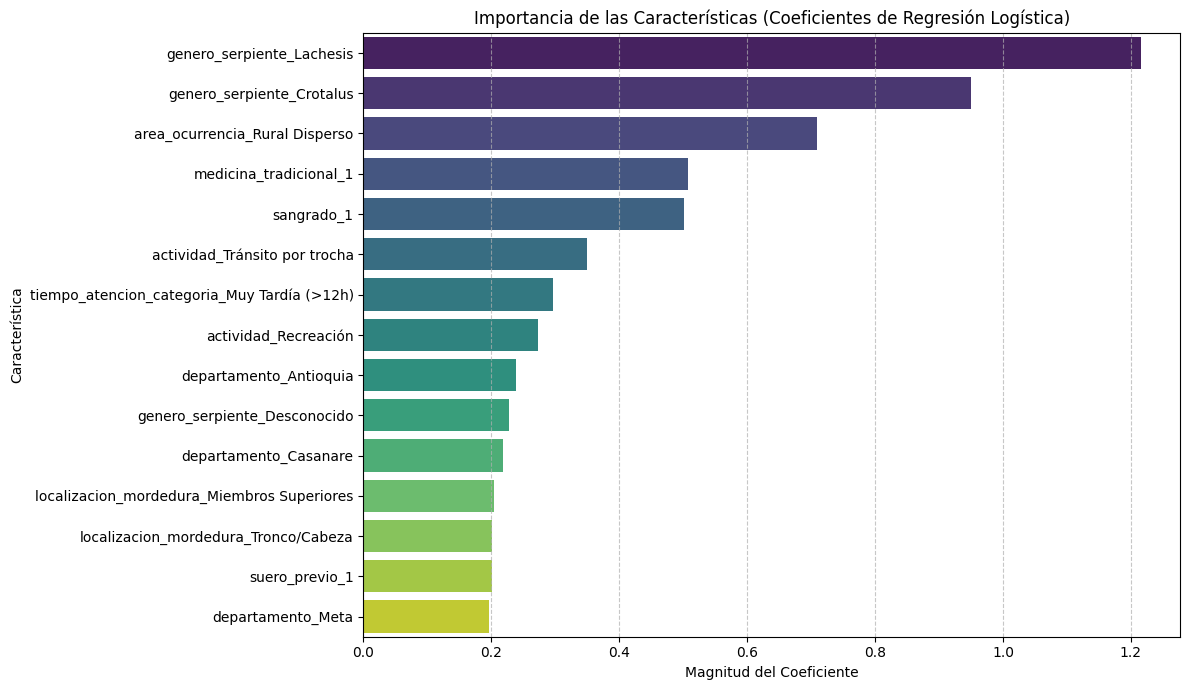

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

# Ordenar por el valor absoluto del coeficiente
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print('Top 10 características más importantes según la Regresión Logística:')
display(feature_importance.head(10))

# Visualizar la importancia de las características
plt.figure(figsize=(12, 7))
sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance.head(15), hue='Feature', palette='viridis', legend=False)
plt.title('Importancia de las Características (Coeficientes de Regresión Logística)')
plt.xlabel('Magnitud del Coeficiente')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 6. Entrenamiento y Evaluación con RandomForestClassifier

Dado que la Regresión Logística mostró un rendimiento moderado, vamos a probar un algoritmo de ensamblaje más potente, como `RandomForestClassifier`, que a menudo captura relaciones más complejas en los datos y puede ofrecer una mejor performance.

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar el modelo RandomForestClassifier
# Usamos random_state para reproducibilidad y un número inicial de estimadores
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # class_weight para manejar desbalance de clases si lo hubiera

# Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

print('¡Modelo RandomForestClassifier entrenado exitosamente!')

¡Modelo RandomForestClassifier entrenado exitosamente!


### 7. Predicciones y Evaluación del RandomForestClassifier

Ahora realizaremos predicciones con el `RandomForestClassifier` y evaluaremos su rendimiento utilizando las mismas métricas detalladas anteriormente.


Métricas del Modelo RandomForestClassifier:
Accuracy: 0.5950
Precision: 0.6336
Recall: 0.7155
F1-Score: 0.6721
ROC AUC Score: 0.6123


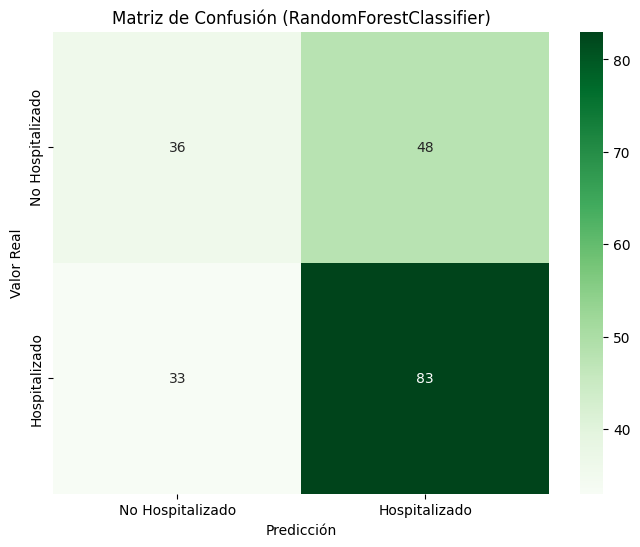

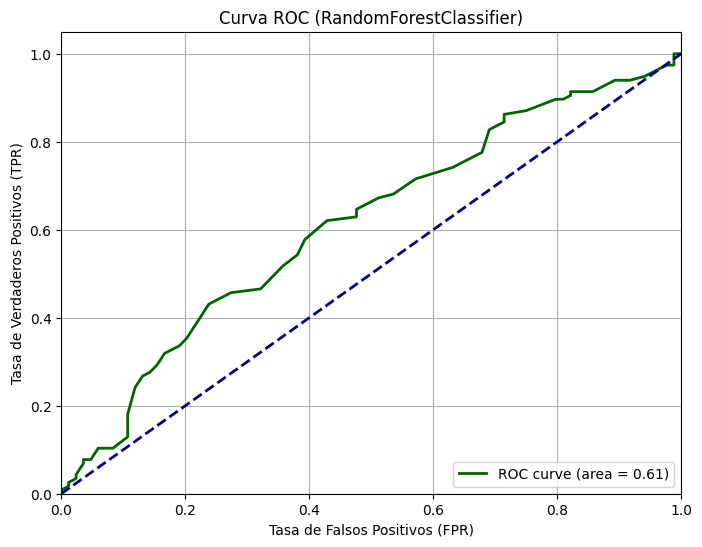

In [19]:
rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calcular y mostrar métricas de clasificación para RandomForest
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print(f'\nMétricas del Modelo RandomForestClassifier:')
print(f'Accuracy: {rf_accuracy:.4f}')
print(f'Precision: {rf_precision:.4f}')
print(f'Recall: {rf_recall:.4f}')
print(f'F1-Score: {rf_f1:.4f}')
print(f'ROC AUC Score: {rf_roc_auc:.4f}')

# Mostrar la Matriz de Confusión para RandomForest
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Hospitalizado', 'Hospitalizado'],
            yticklabels=['No Hospitalizado', 'Hospitalizado'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (RandomForestClassifier)')
plt.show()

# Mostrar la Curva ROC para RandomForest
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {rf_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (RandomForestClassifier)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 8. Optimización de Hiperparámetros con GridSearchCV (RandomForestClassifier)

Para mejorar el rendimiento del `RandomForestClassifier`, realizaremos una búsqueda en cuadrícula de sus hiperparámetros. `GridSearchCV` probará diferentes combinaciones de parámetros para encontrar la configuración óptima que maximice una métrica de evaluación específica (en este caso, la sensibilidad o 'recall', que es crucial en contextos de salud).

In [24]:
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300], # Número de árboles en el bosque
    'max_depth': [5, 10, 15, None], # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10], # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 2, 4], # Número mínimo de muestras requeridas en cada hoja
    'class_weight': ['balanced', None] # Ponderación de clases
}

# Inicializar GridSearchCV
# Usamos 'recall' como la métrica principal ya que es importante para detectar casos positivos (hospitalización)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid,
                           scoring='recall', cv=3, verbose=1, n_jobs=-1)

# Ejecutar la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

print(f'Mejores hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Mejor puntuación (Recall) con los mejores hiperparámetros: {grid_search.best_score_:.4f}')

# Obtener el mejor modelo
best_rf_model = grid_search.best_estimator_

print('\n¡Optimización de hiperparámetros completada!')

Fitting 3 folds for each of 216 candidates, totalling 648 fits


KeyboardInterrupt: 

### 9. Evaluación del Modelo RandomForestClassifier Optimizado

Ahora evaluaremos el `RandomForestClassifier` con los hiperparámetros óptimos encontrados a través de `GridSearchCV`.

In [ ]:
optimized_rf_y_pred = best_rf_model.predict(X_test)
optimized_rf_y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Calcular y mostrar métricas de clasificación para el RandomForest optimizado
optimized_rf_accuracy = accuracy_score(y_test, optimized_rf_y_pred)
optimized_rf_precision = precision_score(y_test, optimized_rf_y_pred)
optimized_rf_recall = recall_score(y_test, optimized_rf_y_pred)
optimized_rf_f1 = f1_score(y_test, optimized_rf_y_pred)
optimized_rf_roc_auc = roc_auc_score(y_test, optimized_rf_y_pred_proba)

print(f'\nMétricas del Modelo RandomForestClassifier Optimizado:')
print(f'Accuracy: {optimized_rf_accuracy:.4f}')
print(f'Precision: {optimized_rf_precision:.4f}')
print(f'Recall: {optimized_rf_recall:.4f}')
print(f'F1-Score: {optimized_rf_f1:.4f}')
print(f'ROC AUC Score: {optimized_rf_roc_auc:.4f}')

# Mostrar la Matriz de Confusión para el RandomForest optimizado
optimized_rf_cm = confusion_matrix(y_test, optimized_rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(optimized_rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Hospitalizado', 'Hospitalizado'],
            yticklabels=['No Hospitalizado', 'Hospitalizado'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (RandomForestClassifier Optimizado)')
plt.show()

# Mostrar la Curva ROC para el RandomForest optimizado
optimized_rf_fpr, optimized_rf_tpr, _ = roc_curve(y_test, optimized_rf_y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(optimized_rf_fpr, optimized_rf_tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {optimized_rf_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (RandomForestClassifier Optimizado)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 8. Optimización de Hiperparámetros con GridSearchCV (RandomForestClassifier)

Para mejorar el rendimiento del `RandomForestClassifier`, realizaremos una búsqueda en cuadrícula de sus hiperparámetros. `GridSearchCV` probará diferentes combinaciones de parámetros para encontrar la configuración óptima que maximice una métrica de evaluación específica (en este caso, la sensibilidad o 'recall', que es crucial en contextos de salud).

In [21]:
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300], # Número de árboles en el bosque
    'max_depth': [5, 10, 15, None], # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10], # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 2, 4], # Número mínimo de muestras requeridas en cada hoja
    'class_weight': ['balanced', None] # Ponderación de clases
}

# Inicializar GridSearchCV
# Usamos 'recall' como la métrica principal ya que es importante para detectar casos positivos (hospitalización)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid,
                           scoring='recall', cv=3, verbose=1, n_jobs=-1)

# Ejecutar la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

print(f'Mejores hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Mejor puntuación (Recall) con los mejores hiperparámetros: {grid_search.best_score_:.4f}')

# Obtener el mejor modelo
best_rf_model = grid_search.best_estimator_

print('\n¡Optimización de hiperparámetros completada!')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Mejores hiperparámetros encontrados: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Mejor puntuación (Recall) con los mejores hiperparámetros: 0.8902

¡Optimización de hiperparámetros completada!


### 9. Evaluación del Modelo RandomForestClassifier Optimizado

Ahora evaluaremos el `RandomForestClassifier` con los hiperparámetros óptimos encontrados a través de `GridSearchCV`.


Métricas del Modelo RandomForestClassifier Optimizado:
Accuracy: 0.6300
Precision: 0.6250
Recall: 0.9052
F1-Score: 0.7394
ROC AUC Score: 0.6466


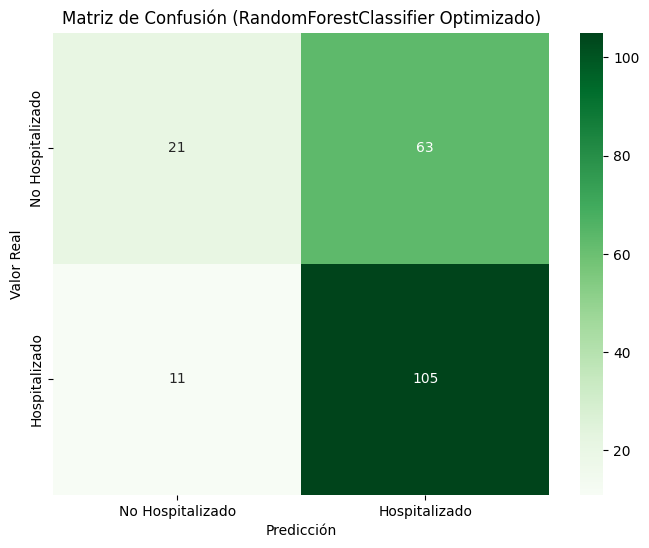

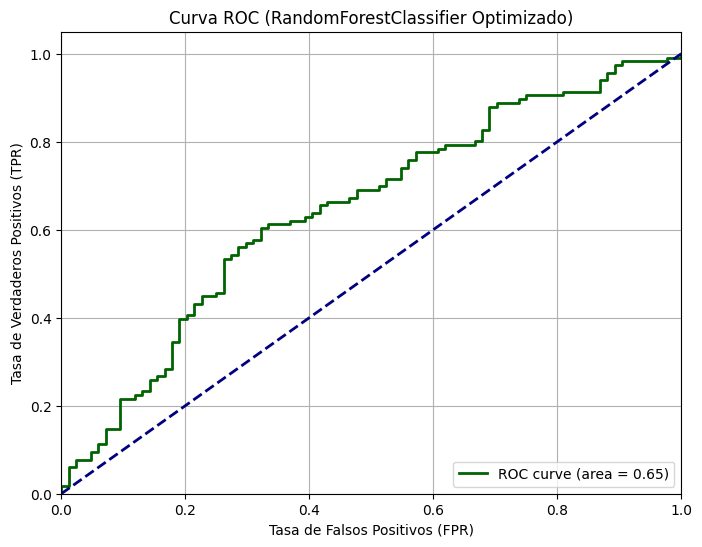

In [23]:
optimized_rf_y_pred = best_rf_model.predict(X_test)
optimized_rf_y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Calcular y mostrar métricas de clasificación para el RandomForest optimizado
optimized_rf_accuracy = accuracy_score(y_test, optimized_rf_y_pred)
optimized_rf_precision = precision_score(y_test, optimized_rf_y_pred)
optimized_rf_recall = recall_score(y_test, optimized_rf_y_pred)
optimized_rf_f1 = f1_score(y_test, optimized_rf_y_pred)
optimized_rf_roc_auc = roc_auc_score(y_test, optimized_rf_y_pred_proba)

print(f'\nMétricas del Modelo RandomForestClassifier Optimizado:')
print(f'Accuracy: {optimized_rf_accuracy:.4f}')
print(f'Precision: {optimized_rf_precision:.4f}')
print(f'Recall: {optimized_rf_recall:.4f}')
print(f'F1-Score: {optimized_rf_f1:.4f}')
print(f'ROC AUC Score: {optimized_rf_roc_auc:.4f}')

# Mostrar la Matriz de Confusión para el RandomForest optimizado
optimized_rf_cm = confusion_matrix(y_test, optimized_rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(optimized_rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Hospitalizado', 'Hospitalizado'],
            yticklabels=['No Hospitalizado', 'Hospitalizado'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (RandomForestClassifier Optimizado)')
plt.show()

# Mostrar la Curva ROC para el RandomForest optimizado
optimized_rf_fpr, optimized_rf_tpr, _ = roc_curve(y_test, optimized_rf_y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(optimized_rf_fpr, optimized_rf_tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {optimized_rf_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (RandomForestClassifier Optimizado)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [27]:
import pandas as pd
import numpy as np
import joblib # Para persistencia del modelo

# --- 1. Crear datos de nuevos pacientes (ejemplo) ---
print('--- Datos de Nuevos Pacientes (Ejemplo) ---')
new_patients_data = pd.DataFrame({
    'edad': [30, 65, 10, 45, 78],
    'sexo': ['F', 'M', 'M', 'F', 'F'],
    'etnia': ['Otros', 'Indigena', 'Afro', 'Otros', 'Otros'],
    'regimen_salud': ['Contributivo', 'Subsidiado', 'No Asegurado', 'Contributivo', 'Subsidiado'],
    'departamento': ['Antioquia', 'Amazonas', 'Chocó', 'Meta', 'Casanare'],
    'area_ocurrencia': ['Cabecera Municipal', 'Rural Disperso', 'Centro Poblado', 'Rural Disperso', 'Cabecera Municipal'],
    'actividad': ['Doméstico', 'Agricultura', 'Tránsito por trocha', 'Recreación', 'Agricultura'],
    'genero_serpiente': ['Bothrops', 'Lachesis', 'Crotalus', 'Desconocido', 'Micrurus'],
    'localizacion_mordedura': ['Miembros Inferiores', 'Miembros Superiores', 'Tronco/Cabeza', 'Miembros Inferiores', 'Miembros Superiores'],
    'tiempo_atencion_h': [2.5, 8.0, 1.0, 5.0, 15.0],
    'medicina_tradicional': [0, 1, 0, 0, 1],
    'edema': [1, 1, 0, 1, 1],
    'sangrado': [0, 1, 1, 0, 1],
    'flictenas': [0, 1, 0, 0, 1],
    'suero_previo': [0, 0, 0, 0, 1]
})
display(new_patients_data)

# --- 2. Aplicar Ingeniería de Características (mismas categorías) ---
print('\n--- Aplicando Ingeniería de Características ---')
bins = [0, 12, 18, 60, 85]
labels = ['Niño', 'Adolescente', 'Adulto', 'Adulto Mayor']
new_patients_data['edad_categoria'] = pd.cut(new_patients_data['edad'], bins=bins, labels=labels, right=False)

bins_tiempo = [0, 3, 6, 12, df_ofidico['tiempo_atencion_h'].max() + 1] # Usar max del dataset original
labels_tiempo = ['Rápida (<3h)', 'Moderada (3-6h)', 'Tardía (6-12h)', 'Muy Tardía (>12h)']
new_patients_data['tiempo_atencion_categoria'] = pd.cut(new_patients_data['tiempo_atencion_h'], bins=bins_tiempo, labels=labels_tiempo, right=False)

# --- 3. Aplicar One-Hot Encoding (asegurando las mismas columnas que X_train) ---
print('\n--- Aplicando One-Hot Encoding ---')
categorical_cols_for_encoding = [
    'sexo', 'etnia', 'regimen_salud', 'departamento',
    'area_ocurrencia', 'actividad', 'genero_serpiente',
    'localizacion_mordedura', 'medicina_tradicional', 'edema',
    'sangrado', 'flictenas', 'suero_previo', 'edad_categoria', 'tiempo_atencion_categoria'
]

new_patients_encoded = pd.get_dummies(new_patients_data, columns=categorical_cols_for_encoding, drop_first=True)

# Reindexar para asegurar que las columnas sean idénticas a las de X_train
# Las columnas que falten en new_patients_encoded se llenarán con 0
# Las columnas adicionales en new_patients_encoded (si las hubiera) se eliminarán
new_patients_processed = new_patients_encoded.reindex(columns=X_train.columns, fill_value=0)
display(new_patients_processed)

# --- 4. Realizar Predicciones con el Modelo Optimizado ---
print('\n--- Realizando Predicciones ---')
predictions_new_patients = best_rf_model.predict(new_patients_processed)
probabilities_new_patients = best_rf_model.predict_proba(new_patients_processed)[:, 1]

new_patients_data['prediccion_hospitalizacion'] = predictions_new_patients
new_patients_data['probabilidad_hospitalizacion'] = probabilities_new_patients.round(4)

print('\nResultados de la predicción para nuevos pacientes:')
display(new_patients_data[['edad', 'genero_serpiente', 'tiempo_atencion_h', 'prediccion_hospitalizacion', 'probabilidad_hospitalizacion']])


# ### 11. Pipeline para Ajustar y Aplicar el Modelo

# Para usar este modelo en un entorno de producción o para nuevas predicciones, el proceso sería el siguiente:

# 1.  **Recopilación de Datos:** Obtener los datos de los nuevos pacientes con las mismas características que se usaron para el entrenamiento.
# 2.  **Ingeniería de Características:** Aplicar exactamente las mismas transformaciones de características: crear `edad_categoria` y `tiempo_atencion_categoria` con los mismos `bins` y `labels`.
# 3.  **Codificación One-Hot:** Aplicar One-Hot Encoding a las variables categóricas, asegurándose de que las columnas resultantes coincidan con las que el modelo fue entrenado (`X_train.columns`). Esto es crucial para evitar errores de dimensionalidad.
# 4.  **Cargar Modelo:** Cargar el modelo guardado (`best_rf_model`) desde el archivo.
# 5.  **Predicción:** Utilizar el modelo cargado para hacer predicciones (`.predict()` o `.predict_proba()`) sobre los datos preprocesados de los nuevos pacientes.
# 6.  **Interpretación:** Interpretar los resultados de la predicción y tomar decisiones.

# ### 12. Persistencia del Modelo (Guardar y Cargar)

# Para que el modelo pueda ser utilizado sin necesidad de reentrenarlo cada vez, podemos guardarlo en un archivo. Aquí usamos `joblib`, que es ideal para modelos de `scikit-learn`.

print('\n--- Guardando el Modelo y Artefactos de Transformación ---')
model_filename = 'random_forest_optimized_model.joblib'
joblib.dump(best_rf_model, model_filename)
print(f'Modelo guardado exitosamente como {model_filename}')

# Guardar los artefactos de la transformación
transformation_pipeline_artifacts = {
    'edad_bins': bins,
    'edad_labels': labels,
    'tiempo_atencion_bins': bins_tiempo,
    'tiempo_atencion_labels': labels_tiempo,
    'ohe_categorical_cols': categorical_cols_for_encoding,
    'model_input_columns': X_train.columns.tolist() # Guardar las columnas de X_train
}
artifacts_filename = 'transformation_pipeline_artifacts.joblib'
joblib.dump(transformation_pipeline_artifacts, artifacts_filename)
print(f'Artefactos de transformación guardados exitosamente como {artifacts_filename}')

print('\n--- Cargando el Modelo y Artefactos de Transformación para verificar ---')
loaded_model = joblib.load(model_filename)
loaded_artifacts = joblib.load(artifacts_filename)
print('Modelo y artefactos cargados exitosamente.')

# Puedes verificar que el modelo cargado funciona haciendo una predicción
# Por ejemplo, prediciendo el primer paciente nuevo con el modelo cargado
first_new_patient_processed = new_patients_processed.iloc[[0]]
loaded_prediction = loaded_model.predict(first_new_patient_processed)
loaded_proba = loaded_model.predict_proba(first_new_patient_processed)[:, 1]

print(f'Predicción del paciente 0 con modelo cargado: {loaded_prediction[0]} (Prob: {loaded_proba[0]:.4f})')
print(f'Predicción original del paciente 0: {new_patients_data.iloc[0]["prediccion_hospitalizacion"]} (Prob: {new_patients_data.iloc[0]["probabilidad_hospitalizacion"]})')


--- Datos de Nuevos Pacientes (Ejemplo) ---


,edad,sexo,etnia,regimen_salud,departamento,area_ocurrencia,actividad,genero_serpiente,localizacion_mordedura,tiempo_atencion_h,medicina_tradicional,edema,sangrado,flictenas,suero_previo
0,30,F,Otros,Contributivo,Antioquia,Cabecera Municipal,Doméstico,Bothrops,Miembros Inferiores,2.5,0,1,0,0,0
1,65,M,Indigena,Subsidiado,Amazonas,Rural Disperso,Agricultura,Lachesis,Miembros Superiores,8.0,1,1,1,1,0
2,10,M,Afro,No Asegurado,Chocó,Centro Poblado,Tránsito por trocha,Crotalus,Tronco/Cabeza,1.0,0,0,1,0,0
3,45,F,Otros,Contributivo,Meta,Rural Disperso,Recreación,Desconocido,Miembros Inferiores,5.0,0,1,0,0,0
4,78,F,Otros,Subsidiado,Casanare,Cabecera Municipal,Agricultura,Micrurus,Miembros Superiores,15.0,1,1,1,1,1



--- Aplicando Ingeniería de Características ---

--- Aplicando One-Hot Encoding ---


,edad,tiempo_atencion_h,sexo_M,etnia_Indigena,etnia_Otros,regimen_salud_No Asegurado,regimen_salud_Subsidiado,departamento_Antioquia,departamento_Casanare,departamento_Chocó,...,edema_1,sangrado_1,flictenas_1,suero_previo_1,edad_categoria_Adolescente,edad_categoria_Adulto,edad_categoria_Adulto Mayor,tiempo_atencion_categoria_Moderada (3-6h),tiempo_atencion_categoria_Tardía (6-12h),tiempo_atencion_categoria_Muy Tardía (>12h)
0,30,2.5,False,False,True,False,False,True,False,False,...,True,False,False,False,False,True,False,False,False,False
1,65,8.0,True,True,False,False,True,False,False,False,...,True,True,True,False,False,False,True,False,True,False
2,10,1.0,True,False,False,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
3,45,5.0,False,False,True,False,False,False,False,False,...,True,False,False,False,False,True,False,True,False,False
4,78,15.0,False,False,True,False,True,False,True,False,...,True,True,True,True,False,False,True,False,False,True



--- Realizando Predicciones ---

Resultados de la predicción para nuevos pacientes:


,edad,genero_serpiente,tiempo_atencion_h,prediccion_hospitalizacion,probabilidad_hospitalizacion
0,30,Bothrops,2.5,0,0.4741
1,65,Lachesis,8.0,1,0.6427
2,10,Crotalus,1.0,0,0.4956
3,45,Desconocido,5.0,1,0.5716
4,78,Micrurus,15.0,1,0.6564



--- Guardando el Modelo y Artefactos de Transformación ---
Modelo guardado exitosamente como random_forest_optimized_model.joblib
Artefactos de transformación guardados exitosamente como transformation_pipeline_artifacts.joblib

--- Cargando el Modelo y Artefactos de Transformación para verificar ---
Modelo y artefactos cargados exitosamente.
Predicción del paciente 0 con modelo cargado: 0 (Prob: 0.4741)
Predicción original del paciente 0: 0 (Prob: 0.4741)
